2025-12-22 04:01:24.627632: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766376084.816164      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766376084.874390      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766376085.322282      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766376085.322321      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766376085.322324      55 computation_placer.cc:177] computation placer alr

Found 24981 files belonging to 22 classes.
Using 19985 files for training.


I0000 00:00:1766376116.223864      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 24981 files belonging to 22 classes.
Using 4996 files for validation.
Detected Classes: ['anthracnose', 'bacterial blight', 'brown spot', 'fall armyworm', 'grasshoper', 'green mite', 'gumosis', 'healthy_cashew', 'healthy_cassava', 'healthy_maize', 'healthy_tomato', 'leaf beetle', 'leaf blight', 'leaf blight_tomato', 'leaf curl_tomato', 'leaf miner', 'leaf spot', 'mosaic', 'red rust', 'septoria leaf spot_tomato', 'streak virus', 'verticulium wilt_tomato']
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "ResNet50_Transformer_NoES"

...

625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 169ms/step - accuracy: 0.9924 - loss: 0.0269 - val_accuracy: 0.8877 - val_loss: 0.5469
Epoch 21/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9936 - loss: 0.0191
Epoch 21: val_accuracy did not improve from 0.88771
625/625 ━━━━━━━━━━━━━━━━━━━━ 105s 168ms/step - accuracy: 0.9936 - loss: 0.0192 - val_accuracy: 0.8555 - val_loss: 0.6393
Epoch 22/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9834 - loss: 0.0487
Epoch 22: val_accuracy improved from 0.88771 to 0.89492, saving model to resnet50_transformer_no_dropout_no_earlystop.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 170ms/step - accuracy: 0.9834 - loss: 0.0487 - val_accuracy: 0.8949 - val_loss: 0.5194
Epoch 23/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9952 - loss: 0.0148
Epoch 23: val_accuracy did not improve from 0.89492
625/625 ━━━━━━━━━━━━━━━━━━━━ 105s 168ms/step - accuracy: 0.9952 - loss: 0.0148 - val_accuracy: 0.8803 - val_loss: 0.5654
Epoch 24/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9929 - loss: 0.0218
Epoch 24: val_accuracy did not improve from 0.89492
625/625 ━━━━━━━━━━━━━━━━━━━━ 105s 167ms/step - accuracy: 0.9929 - loss: 0.0218 - val_accuracy: 0.8687 - val_loss: 0.6648
Epoch 25/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9904 - loss: 0.0257
Epoch 25: val_accuracy improved from 0.89492 to 0.90192, saving model to resnet50_transformer_no_dropout_no_earlystop.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 169ms/step - accuracy: 0.9904 - loss: 0.0257 - val_accuracy: 0.9019 - val_loss: 0.5052
Epoch 26/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9963 - loss: 0.0155
Epoch 26: val_accuracy did not improve from 0.90192
625/625 ━━━━━━━━━━━━━━━━━━━━ 104s 167ms/step - accuracy: 0.9963 - loss: 0.0155 - val_accuracy: 0.8875 - val_loss: 0.5869
Epoch 27/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9892 - loss: 0.0351
Epoch 27: val_accuracy did not improve from 0.90192
625/625 ━━━━━━━━━━━━━━━━━━━━ 104s 167ms/step - accuracy: 0.9892 - loss: 0.0351 - val_accuracy: 0.8901 - val_loss: 0.5016
Epoch 28/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9934 - loss: 0.0182
Epoch 28: val_accuracy did not improve from 0.90192
625/625 ━━━━━━━━━━━━━━━━━━━━ 105s 168ms/step - accuracy: 0.9934 - loss: 0.0182 - val_accuracy: 0.8987 - val_loss: 0.4857
Epoch 29/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9979 - loss: 0.0060
Epoc

625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 173ms/step - accuracy: 0.9990 - loss: 0.0058 - val_accuracy: 0.9067 - val_loss: 0.4978
Epoch 42/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9999 - loss: 7.1000e-04
Epoch 42: val_accuracy improved from 0.90673 to 0.90933, saving model to resnet50_transformer_no_dropout_no_earlystop.h5


625/625 ━━━━━━━━━━━━━━━━━━━━ 108s 173ms/step - accuracy: 0.9999 - loss: 7.0961e-04 - val_accuracy: 0.9093 - val_loss: 0.5028
Epoch 43/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9999 - loss: 5.3420e-04
Epoch 43: val_accuracy did not improve from 0.90933
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 171ms/step - accuracy: 0.9999 - loss: 5.3388e-04 - val_accuracy: 0.9085 - val_loss: 0.5097
Epoch 44/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9833 - loss: 0.0593
Epoch 44: val_accuracy did not improve from 0.90933
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 171ms/step - accuracy: 0.9833 - loss: 0.0593 - val_accuracy: 0.8789 - val_loss: 0.5273
Epoch 45/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9931 - loss: 0.0231
Epoch 45: val_accuracy did not improve from 0.90933
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 172ms/step - accuracy: 0.9931 - loss: 0.0231 - val_accuracy: 0.8947 - val_loss: 0.5245
Epoch 46/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9979 - loss:

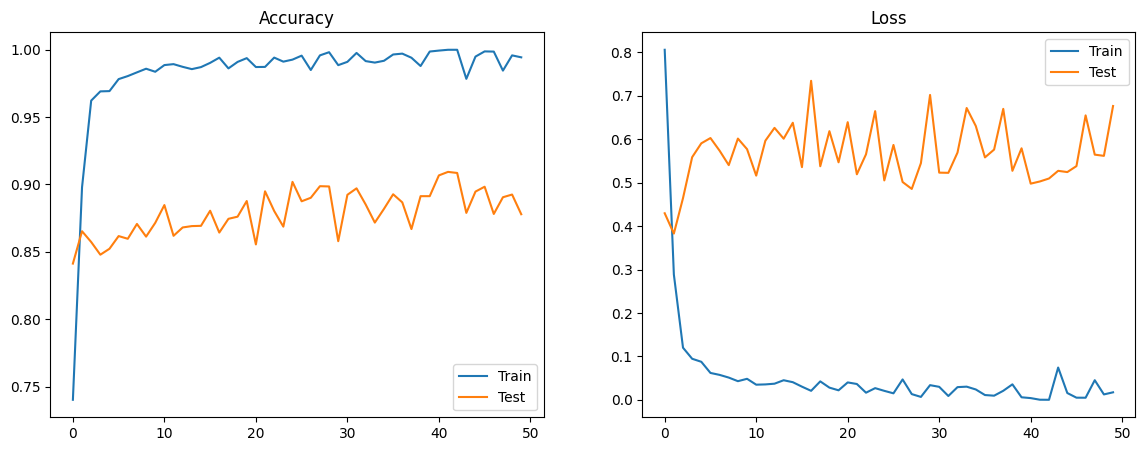


Classification Report:

                           precision    recall  f1-score   support

              anthracnose     0.9413    0.9284    0.9348       363
         bacterial blight     0.9114    0.9187    0.9150       504
               brown spot     0.9745    0.8508    0.9085       315
            fall armyworm     0.8947    0.7391    0.8095        46
               grasshoper     0.9571    0.7528    0.8428        89
               green mite     0.8981    0.9343    0.9158       198
                  gumosis     0.9870    0.9744    0.9806        78
           healthy_cashew     0.9787    0.9871    0.9829       233
          healthy_cassava     0.9442    0.9821    0.9628       224
            healthy_maize     0.7959    0.7091    0.7500        55
           healthy_tomato     0.8761    0.9706    0.9209       102
              leaf beetle     0.8908    0.9714    0.9294       210
              leaf blight     0.7343    0.8000    0.7657       190
       leaf blight_tomato     0.7313

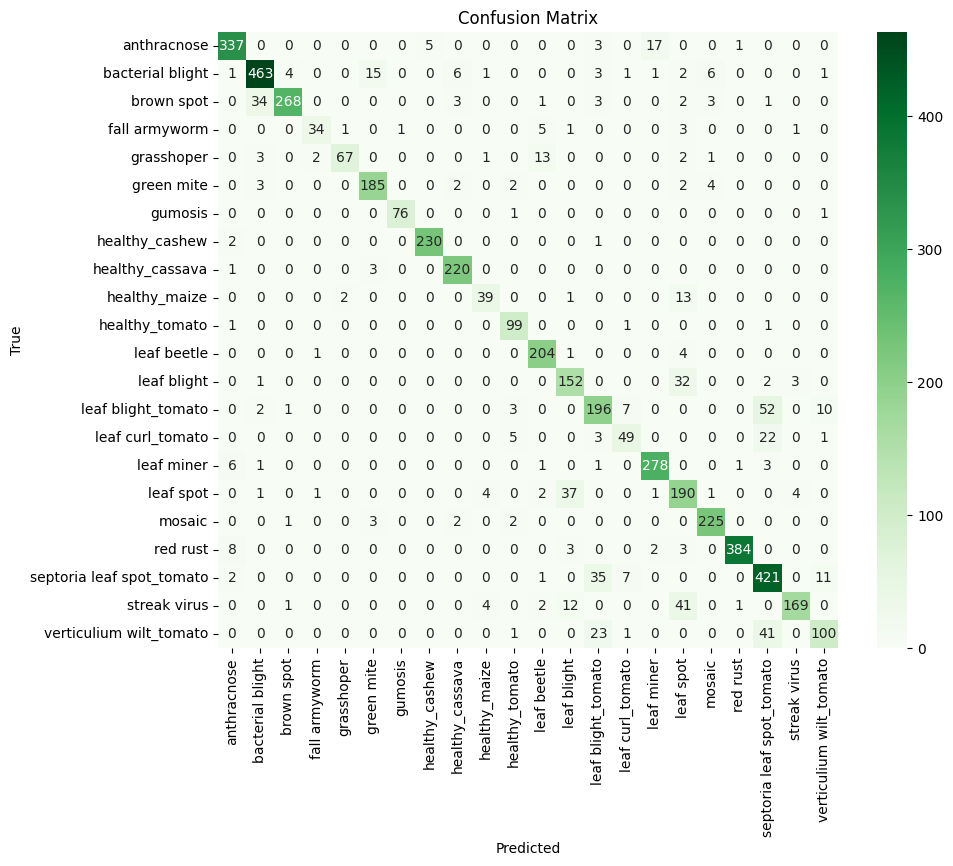

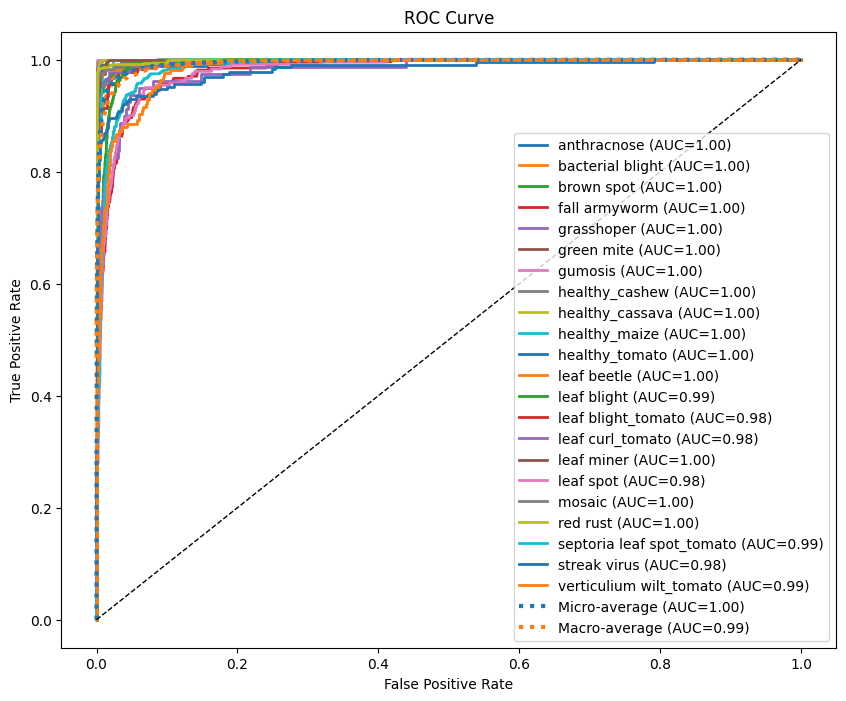

Model saved successfully.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import seaborn as sns

# ==============================================================
# Configuration
# ==============================================================
data_dir = "/kaggle/input/ccmt-2008-mnit/New folder"
img_size = (224, 224)
batch_size = 32
seed = 42
num_epochs = 50
learning_rate = 1e-4
model_save_path = "resnet50_transformer_no_dropout_no_earlystop.h5"

# ==============================================================
# Dataset Loading (20% Train, 80% Test)
# ==============================================================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="categorical",
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="categorical",
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Detected Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

# ==============================================================
# Transformer Encoder (NO DROPOUT)
# ==============================================================
def transformer_encoder(inputs, head_size, num_heads, ff_dim):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=head_size
    )(x, x)
    x = layers.Add()([x, inputs])

    y = layers.LayerNormalization(epsilon=1e-6)(x)
    y = layers.Dense(ff_dim, activation="relu")(y)
    y = layers.Dense(x.shape[-1])(y)

    return layers.Add()([x, y])

# ==============================================================
# Model Architecture (NO DROPOUT)
# ==============================================================
def build_model(input_shape=(224,224,3),
                transformer_depth=2,
                head_dim=64,
                num_heads=4,
                ff_dim=128):

    inputs = layers.Input(shape=input_shape)

    # Normalize to [-1, 1]
    x = layers.Rescaling(1./127.5)(inputs)
    x = layers.Rescaling(1., offset=-1.0)(x)

    # ResNet50 Backbone
    backbone = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    backbone.trainable = True
    x = backbone(x)

    # Projection
    x = layers.Conv2D(head_dim, kernel_size=1, activation="relu")(x)

    # Feature map → sequence
    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    seq_len = h * w
    x = layers.Reshape((seq_len, c))(x)

    # Positional Embedding
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_embed = layers.Embedding(input_dim=seq_len, output_dim=c)(positions)
    x = x + pos_embed

    # Transformer Blocks
    for _ in range(transformer_depth):
        x = transformer_encoder(
            x,
            head_size=head_dim,
            num_heads=num_heads,
            ff_dim=ff_dim
        )

    # Classifier
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(256, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs, name="ResNet50_Transformer_NoES")

# ==============================================================
# Build & Compile
# ==============================================================
model = build_model(input_shape=img_size + (3,))
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ==============================================================
# Train Model (NO EARLY STOP)
# ==============================================================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        model_save_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

history = model.fit(
    train_ds,
    epochs=num_epochs,
    validation_data=test_ds,
    callbacks=callbacks
)

# ==============================================================
# Plot Accuracy & Loss
# ==============================================================
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Test")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Test")
plt.title("Loss")
plt.legend()

plt.show()

# ==============================================================
# Evaluation
# ==============================================================
y_true, y_pred = [], []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ==============================================================
# ROC Curve (Micro & Macro)
# ==============================================================
y_true_bin = label_binarize(y_true, classes=range(num_classes))

y_score = []
for images, _ in test_ds:
    y_score.extend(model.predict(images, verbose=0))
y_score = np.array(y_score)

fpr, tpr, roc_auc = {}, {}, {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(
    y_true_bin.ravel(),
    y_score.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(10,8))
colors = cycle(plt.cm.tab10.colors)

for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], lw=2, color=color,
             label=f"{class_names[i]} (AUC={roc_auc[i]:.2f})")

plt.plot(fpr["micro"], tpr["micro"], linestyle=":", linewidth=3,
         label=f"Micro-average (AUC={roc_auc['micro']:.2f})")

plt.plot(fpr["macro"], tpr["macro"], linestyle=":", linewidth=3,
         label=f"Macro-average (AUC={roc_auc['macro']:.2f})")

plt.plot([0,1], [0,1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# ==============================================================
# Save Final Model
# ==============================================================
model.save("final_" + model_save_path)
print("Model saved successfully.")
